In [ ]:
!pip3 install face_recognition

Make known and unknown directories

In [ ]:
!mkdir known unknown

mkdir: cannot create directory ‘known’: File exists
mkdir: cannot create directory ‘unknown’: File exists


Now upload your images (left click on files, import into the right folders)

* Base models in known with name as file name
* Pictures of these people in unknown

In [ ]:
from PIL import Image, ImageDraw
import face_recognition
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
import face_recognition

In [ ]:
def draw_rec(url1, url2, url3):
  face1_image = face_recognition.load_image_file(url1)
  face1_face_encoding = face_recognition.face_encodings(face1_image)[0]

  face2_image = face_recognition.load_image_file(url2)
  face2_face_encoding = face_recognition.face_encodings(face2_image)[0]

  known_face_encodings = [
      face1_face_encoding,
      face2_face_encoding
  ]
  known_face_names = [
      "Messi",
      "Ronaldo"
  ]

  unknown_image = face_recognition.load_image_file(url3)

  face_locations = face_recognition.face_locations(unknown_image)
  face_encodings = face_recognition.face_encodings(unknown_image, face_locations)

  pil_image = Image.fromarray(unknown_image)
  draw = ImageDraw.Draw(pil_image)

  for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
      matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
      name = "Unknown"

      if True in matches:
          first_match_index = matches.index(True)
          name = known_face_names[first_match_index]

      draw.rectangle(((left, top), (right, bottom)), outline=(0, 0, 255))

      left_bbox, top_bbox, right_bbox, bottom_bbox = draw.textbbox((0, 0), name)
      text_width = right_bbox - left_bbox
      text_height = bottom_bbox - top_bbox

      draw.rectangle(((left, bottom - text_height - 10), (right, bottom)), fill=(0, 0, 255), outline=(0, 0, 255))
      draw.text((left + 6, bottom - text_height - 5), name, fill=(255, 255, 255, 255))

  del draw
  plt.imshow(pil_image, aspect='auto')

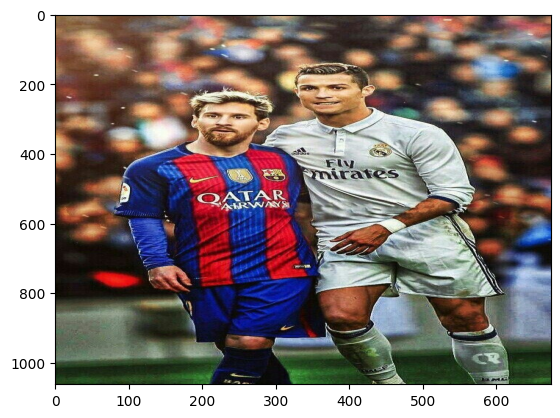

In [ ]:
plt.imshow(Image.fromarray(face_recognition.load_image_file("/content/messi and ronaldo.jpg")), aspect='auto')

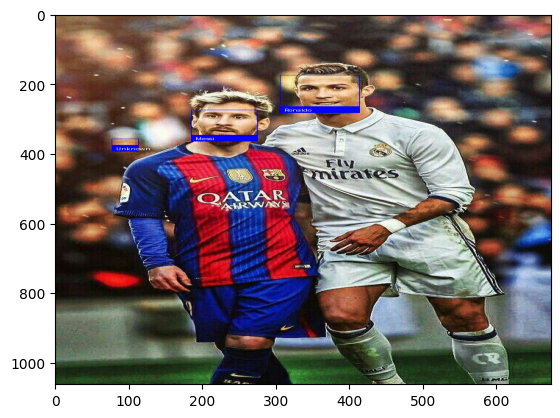

In [ ]:
draw_rec("known/messi.jpg", "known/ronaldo.jpg", "/content/messi and ronaldo.jpg")